# py-TSCAN — visualisation R⇄Py parity

`plotmclust` (PCA scatter + MST + cluster IDs) on the lpsdata fixture.

## 1. Generate side-by-side renders

In [1]:
import subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
PORT = Path('..').resolve(); sys.path.insert(0, str(PORT))
OUT = PORT/'examples'/'plot_compare'; OUT.mkdir(exist_ok=True)
# R reference
r_script = f'''suppressPackageStartupMessages(library(TSCAN)); suppressPackageStartupMessages(library(ggplot2))
data(lpsdata); pd <- preprocess(lpsdata); mc <- exprmclust(pd)
p <- plotmclust(mc)
ggsave("{OUT}/R_mclust.png", p, width=6, height=5, dpi=100)'''
import tempfile
with tempfile.NamedTemporaryFile('w', suffix='.R', delete=False) as f:
    f.write(r_script); r_path = f.name
subprocess.run(['conda','run','-p','/scratch/users/steorra/env/CMAP','Rscript', r_path], check=True, capture_output=True)
# Py
import pytscan
from ggplot2_py import ggsave
expr_path = PORT/'data'/'fixture_lpsdata.csv'
expr = pd.read_csv(expr_path, index_col=0)
proc = pytscan.preprocess(expr); res = pytscan.exprmclust(proc)
ggsave(str(OUT/'Py_mclust.png'), plot=pytscan.plotmclust(res), width=6, height=5, dpi=100)
print('done')

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/ggplot2_py/layer.py:932: UserWarning: Ignoring unknown parameters: `size`
  cli_warn(


Saving 6 x 5 in image to /scratch/users/steorra/analysis/omicverse_traj_dev/py-TSCAN/examples/plot_compare/Py_mclust.png


done


## 2. plotmclust

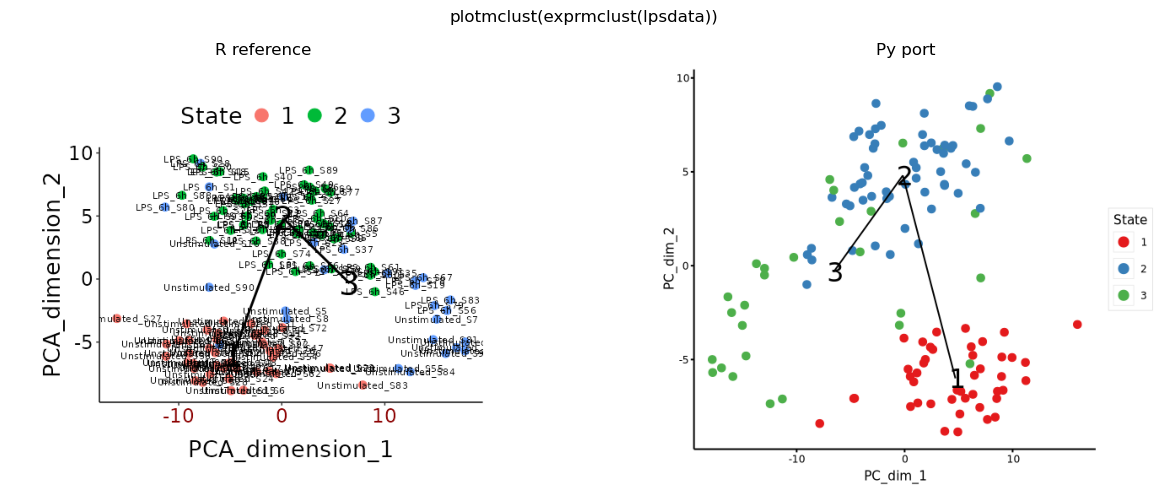

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
a1.imshow(Image.open('plot_compare/R_mclust.png')); a1.set_title('R reference'); a1.axis('off')
a2.imshow(Image.open('plot_compare/Py_mclust.png')); a2.set_title('Py port'); a2.axis('off')
plt.suptitle('plotmclust(exprmclust(lpsdata))'); plt.tight_layout(); plt.show()

PCA scatter coloured by mclust cluster ID + MST overlay + cluster centroid labels. R uses Set1 brewer; Py uses the same palette.